IPUMS rows: 6645362
Years:
YEAR
2019    3239553
2023    3405809
Name: count, dtype: int64

INDNAICS examples:
INDNAICS_clean
0        2688173
6111      256426
23        253952
722Z      227233
622M      166624
611M1     120475
5415       78019
92MP       70910
44511      64762
713Z       61430
531M       51176
6214       50446
5416       48348
6241       45148
5241       44706
484        44675
6211       44566
5413       41000
5411       40870
6244       40303
Name: count, dtype: int64

ACS employed rows after NAICS cleaning: 3113349

ACS NAICS2 counts:
naics2
11     45306
21     14258
22     28258
23    201615
31     47109
32     79462
33    180249
42     71445
44    183633
45    130100
48     92436
49     50510
51     59539
52    148358
53     57777
54    257694
55      3993
56    119168
61    323079
62    431883
71     69015
72    192799
81    149050
92    176613
Name: count, dtype: int64


/tmp/ipykernel_10897/3711394386.py:83: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({



ACS wide:
   naics2  wfh_share_2019  wfh_share_2023  remote_change  college_share_2019
0      11        0.128371        0.136652       0.008280            0.167226
1      21        0.026348        0.063663       0.037315            0.258823
2      22        0.023561        0.124643       0.101082            0.343136
3      23        0.047903        0.074161       0.026258            0.137414
4      31        0.030017        0.077573       0.047556            0.200070
5      32        0.035528        0.106750       0.071222            0.291775
6      33        0.035790        0.112850       0.077059            0.314196
7      42        0.067014        0.144486       0.077472            0.313602
8      44        0.028076        0.064579       0.036502            0.193959
9      45        0.050410        0.094940       0.044529            0.208877
10     48        0.048774        0.086989       0.038215            0.196633
11     49        0.019092        0.052104       0.033012         

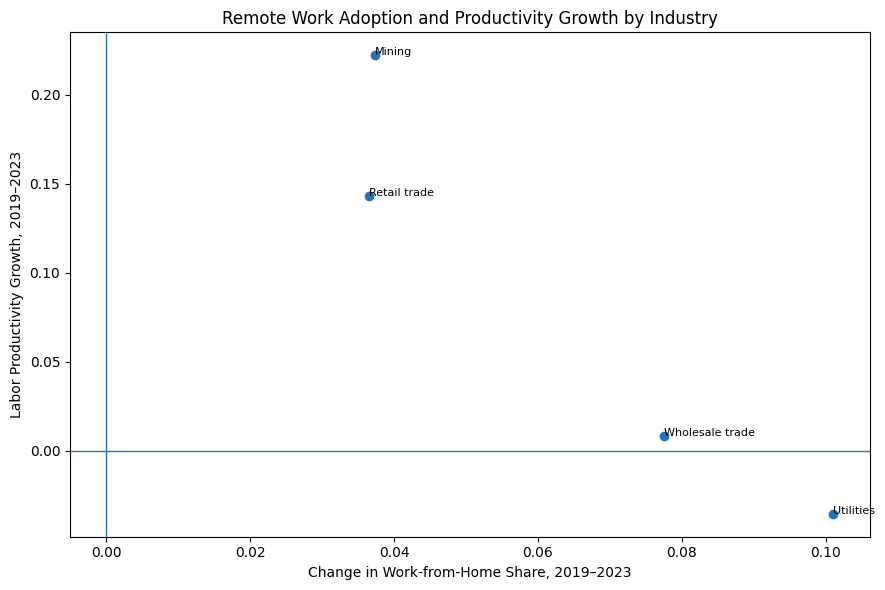

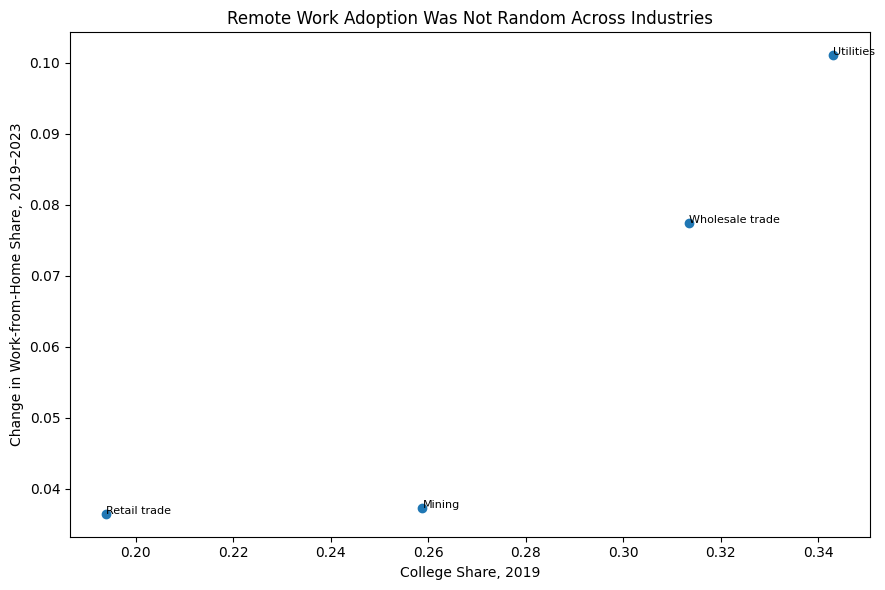


Saved:
- jrl_004_remote_work_productivity_dataset.csv


In [8]:
# ============================================================
# JRL #004 — Remote Work and Productivity
# One-block Google Colab script
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

IPUMS_FILE = "usa_00002.dat.gz"
BLS_FILE = "labor-productivity-detailed-industries.xlsx"

# -----------------------------
# 1. Read IPUMS fixed-width data
# -----------------------------

colspecs = [
    (0, 4),      # YEAR
    (73, 83),    # PERWT
    (83, 85),    # EDUC
    (85, 88),    # EDUCD
    (88, 89),    # EMPSTAT
    (98, 106),   # INDNAICS
    (106, 108),  # TRANWORK
]

names = [
    "YEAR", "PERWT", "EDUC", "EDUCD",
    "EMPSTAT", "INDNAICS", "TRANWORK"
]

acs = pd.read_fwf(
    IPUMS_FILE,
    colspecs=colspecs,
    names=names,
    compression="gzip",
    dtype=str
)

for col in ["YEAR", "PERWT", "EDUC", "EDUCD", "EMPSTAT", "TRANWORK"]:
    acs[col] = pd.to_numeric(acs[col], errors="coerce")

acs["INDNAICS_clean"] = acs["INDNAICS"].astype(str).str.strip()

print("IPUMS rows:", len(acs))
print("Years:")
print(acs["YEAR"].value_counts().sort_index())
print("\nINDNAICS examples:")
print(acs["INDNAICS_clean"].value_counts().head(20))

# -----------------------------
# 2. Build ACS remote work + education variables
# -----------------------------

acs_emp = acs[acs["EMPSTAT"] == 1].copy()

acs_emp["wfh"] = (acs_emp["TRANWORK"] == 80).astype(int)
acs_emp["college"] = (acs_emp["EDUCD"] >= 101).astype(int)

# Flexible NAICS extraction:
# IPUMS INDNAICS can contain strings/suffixes, so extract first 2 digits.
acs_emp["naics2"] = acs_emp["INDNAICS_clean"].str.extract(r"(\d{2})")[0]

acs_emp = acs_emp[
    acs_emp["naics2"].notna() &
    ~acs_emp["naics2"].isin(["00", "99"])
].copy()

print("\nACS employed rows after NAICS cleaning:", len(acs_emp))
print("\nACS NAICS2 counts:")
print(acs_emp["naics2"].value_counts().sort_index())

def weighted_mean(group, value_col, weight_col="PERWT"):
    valid = group[[value_col, weight_col]].dropna()
    if len(valid) == 0 or valid[weight_col].sum() == 0:
        return np.nan
    return np.average(valid[value_col], weights=valid[weight_col])

acs_industry = (
    acs_emp
    .groupby(["YEAR", "naics2"])
    .apply(lambda x: pd.Series({
        "wfh_share": weighted_mean(x, "wfh"),
        "college_share": weighted_mean(x, "college"),
        "workers_weighted": x["PERWT"].sum()
    }))
    .reset_index()
)

acs_wide = acs_industry.pivot(
    index="naics2",
    columns="YEAR",
    values=["wfh_share", "college_share", "workers_weighted"]
)

acs_wide.columns = [f"{var}_{year}" for var, year in acs_wide.columns]
acs_wide = acs_wide.reset_index()

required_acs_cols = [
    "wfh_share_2019", "wfh_share_2023",
    "college_share_2019", "workers_weighted_2019"
]

missing = [c for c in required_acs_cols if c not in acs_wide.columns]
if missing:
    raise ValueError(f"Missing expected ACS columns: {missing}")

acs_wide["remote_change"] = acs_wide["wfh_share_2023"] - acs_wide["wfh_share_2019"]

print("\nACS wide:")
print(acs_wide[[
    "naics2", "wfh_share_2019", "wfh_share_2023",
    "remote_change", "college_share_2019"
]].head(30))

# -----------------------------
# 3. Read BLS productivity data
# -----------------------------

prod = pd.read_excel(BLS_FILE, sheet_name="MachineReadable")

prod.columns = [
    "sector", "naics", "industry", "digit", "basis",
    "measure", "units", "year", "value"
]

prod["year"] = pd.to_numeric(prod["year"], errors="coerce")
prod["value"] = pd.to_numeric(prod["value"], errors="coerce")
prod["naics"] = prod["naics"].astype(str).str.strip()
prod["naics2"] = prod["naics"].str.extract(r"(\d{2})")[0]

prod_lp = prod[
    (prod["measure"] == "Labor productivity") &
    (prod["basis"] == "All workers") &
    (prod["units"] == "Index (2017=100)") &
    (prod["year"].isin([2019, 2023]))
].copy()

# Prefer 2-digit BLS industries for clean merge
prod_lp_2digit = prod_lp[prod_lp["digit"] == "2-Digit"].copy()

prod_wide = (
    prod_lp_2digit
    .pivot_table(
        index=["naics2", "industry"],
        columns="year",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

prod_wide.columns.name = None
prod_wide = prod_wide.rename(columns={
    2019: "prod_2019",
    2023: "prod_2023"
})

prod_wide["prod_growth"] = prod_wide["prod_2023"] / prod_wide["prod_2019"] - 1

print("\nBLS productivity industries:")
print(prod_wide[["naics2", "industry", "prod_2019", "prod_2023", "prod_growth"]])
print("BLS industries:", len(prod_wide))

# -----------------------------
# 4. Merge ACS + BLS
# -----------------------------

df = pd.merge(prod_wide, acs_wide, on="naics2", how="inner")

df = df.dropna(subset=[
    "prod_growth",
    "remote_change",
    "college_share_2019",
    "wfh_share_2019",
    "wfh_share_2023"
]).copy()

df = df.sort_values("remote_change", ascending=False).reset_index(drop=True)

print("\n====================================================")
print("FINAL MERGED DATASET")
print("====================================================")
print("Final sample size:", len(df))
print(df[[
    "naics2", "industry",
    "prod_growth",
    "wfh_share_2019",
    "wfh_share_2023",
    "remote_change",
    "college_share_2019"
]].to_string(index=False))

# -----------------------------
# 5. Regressions
# -----------------------------

def run_ols(data, y_col, x_cols, label):
    y = data[y_col]
    X = sm.add_constant(data[x_cols])
    model = sm.OLS(y, X).fit(cov_type="HC1")
    print("\n====================================================")
    print(label)
    print("====================================================")
    print(model.summary())
    return model

if len(df) >= 6:
    model1 = run_ols(
        df,
        "prod_growth",
        ["remote_change"],
        "MODEL 1: Productivity Growth ~ Remote Work Growth"
    )

    model2 = run_ols(
        df,
        "prod_growth",
        ["remote_change", "college_share_2019"],
        "MODEL 2: Add College Share Control"
    )

    comparison = pd.DataFrame({
        "model": ["Model 1", "Model 2"],
        "remote_change_coef": [
            model1.params.get("remote_change", np.nan),
            model2.params.get("remote_change", np.nan)
        ],
        "remote_change_pvalue": [
            model1.pvalues.get("remote_change", np.nan),
            model2.pvalues.get("remote_change", np.nan)
        ],
        "r_squared": [model1.rsquared, model2.rsquared],
        "n": [int(model1.nobs), int(model2.nobs)]
    })

    print("\nCoefficient comparison:")
    print(comparison.to_string(index=False))

else:
    print("\nWARNING: Final sample size is too small for meaningful regression.")
    print("We can still inspect scatterplots, but do not interpret coefficients.")

# -----------------------------
# 6. Figures
# -----------------------------

plt.figure(figsize=(9, 6))
plt.scatter(df["remote_change"], df["prod_growth"])

for _, row in df.iterrows():
    plt.text(
        row["remote_change"],
        row["prod_growth"],
        row["industry"],
        fontsize=8
    )

plt.xlabel("Change in Work-from-Home Share, 2019–2023")
plt.ylabel("Labor Productivity Growth, 2019–2023")
plt.title("Remote Work Adoption and Productivity Growth by Industry")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
plt.scatter(df["college_share_2019"], df["remote_change"])

for _, row in df.iterrows():
    plt.text(
        row["college_share_2019"],
        row["remote_change"],
        row["industry"],
        fontsize=8
    )

plt.xlabel("College Share, 2019")
plt.ylabel("Change in Work-from-Home Share, 2019–2023")
plt.title("Remote Work Adoption Was Not Random Across Industries")
plt.tight_layout()
plt.show()

# -----------------------------
# 7. Save outputs
# -----------------------------

df.to_csv("jrl_004_remote_work_productivity_dataset.csv", index=False)

if len(df) >= 6:
    comparison.to_csv("jrl_004_regression_comparison.csv", index=False)

print("\nSaved:")
print("- jrl_004_remote_work_productivity_dataset.csv")
if len(df) >= 6:
    print("- jrl_004_regression_comparison.csv")

In [9]:
print(prod["digit"].value_counts())
print(sorted(prod["digit"].dropna().unique()))

digit
4-Digit    243328
5-Digit    166805
6-Digit     97438
3-Digit     46425
2-Digit      4375
Custom       1573
Name: count, dtype: int64
['2-Digit', '3-Digit', '4-Digit', '5-Digit', '6-Digit', 'Custom']


In [10]:
# How many labor productivity observations by digit level?

tmp = prod[
    (prod["measure"] == "Labor productivity") &
    (prod["basis"] == "All workers") &
    (prod["units"] == "Index (2017=100)") &
    (prod["year"].isin([2019, 2023]))
].copy()

print(tmp["digit"].value_counts())

digit
4-Digit    319
5-Digit    256
6-Digit    170
3-Digit     98
2-Digit      9
Custom       3
Name: count, dtype: int64


In [11]:
tmp3 = tmp[tmp["digit"] == "3-Digit"]

print(tmp3[["naics", "industry"]].drop_duplicates().head(50))
print("3-digit industries:", tmp3["industry"].nunique())

       naics                                           industry
907      211                             Oil and gas extraction
1782     212                         Mining, except oil and gas
2657     213                      Support activities for mining
13157    221                                          Utilities
18407    311                                 Food manufacturing
19277    312                     Beverages and tobacco products
20147    313                                      Textile mills
21017    314                              Textile product mills
21887    315                                            Apparel
22757    316                        Leather and allied products
23627    321                                      Wood products
24497    322                           Paper and paper products
25367    323            Printing and related support activities
27444    324                        Petroleum and coal products
29521    325                            

In [12]:
acs_wide.sort_values(
    "remote_change",
    ascending=False
)[[
    "naics2",
    "remote_change",
    "college_share_2019"
]]

,naics2,remote_change,college_share_2019
13,52,0.227760,0.553390
15,54,0.211466,0.691041
12,51,0.203816,0.532813
16,55,0.191439,0.588818
2,22,0.101082,0.343136
17,56,0.086182,0.202971
23,92,0.083844,0.447984
7,42,0.077472,0.313602
6,33,0.077059,0.314196
5,32,0.071222,0.291775


In [13]:
from scipy.stats import pearsonr

corr, p = pearsonr(
    acs_wide["remote_change"],
    acs_wide["college_share_2019"]
)

print("Correlation:", round(corr,3))
print("P-value:", p)

Correlation: 0.767
P-value: 1.2169329914042953e-05


ACS employed rows with 3-digit NAICS: 2761952
Unique ACS 3-digit industries: 94


/tmp/ipykernel_10897/218980396.py:76: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({



ACS 3-digit sample:
  naics3  wfh_share_2019  wfh_share_2023  college_share_2019  \
0    111        0.119265        0.121611            0.154509   
1    112        0.188280        0.176537            0.176543   
2    113        0.053037        0.138249            0.208081   
3    114        0.060851        0.096744            0.180115   
4    115        0.075416        0.139393            0.179769   

   college_share_2023  workers_weighted_2019  workers_weighted_2023  \
0            0.185609            105374500.0            113617400.0   
1            0.193099             53556800.0             45730900.0   
2            0.272149             13996000.0             13383100.0   
3            0.209084              4430500.0              4526400.0   
4            0.282712             16908900.0             16101200.0   

   remote_change  
0       0.002346  
1      -0.011743  
2       0.085212  
3       0.035893  
4       0.063977  

BLS 3-digit productivity industries: 49
   naics3   

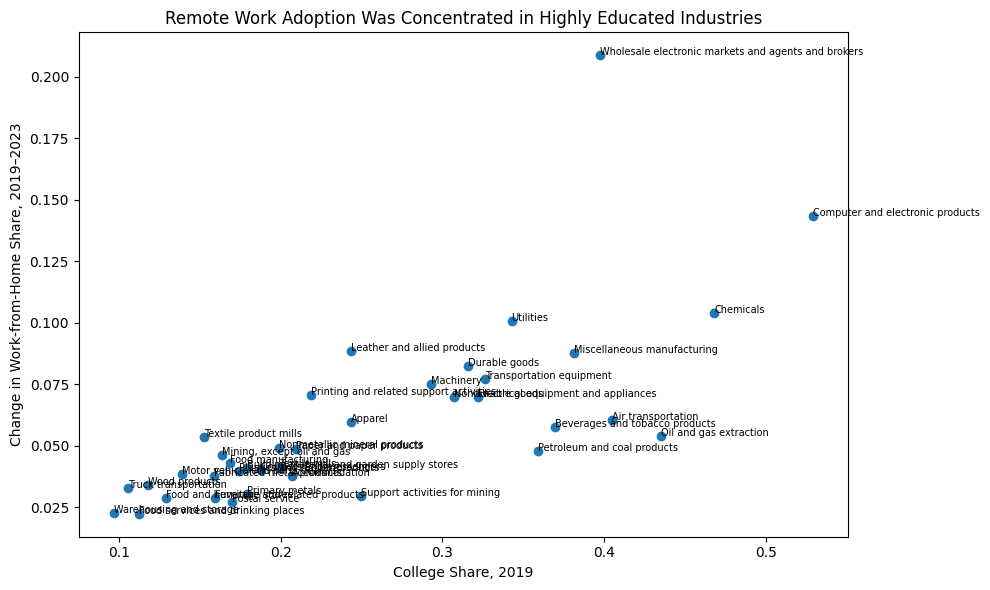

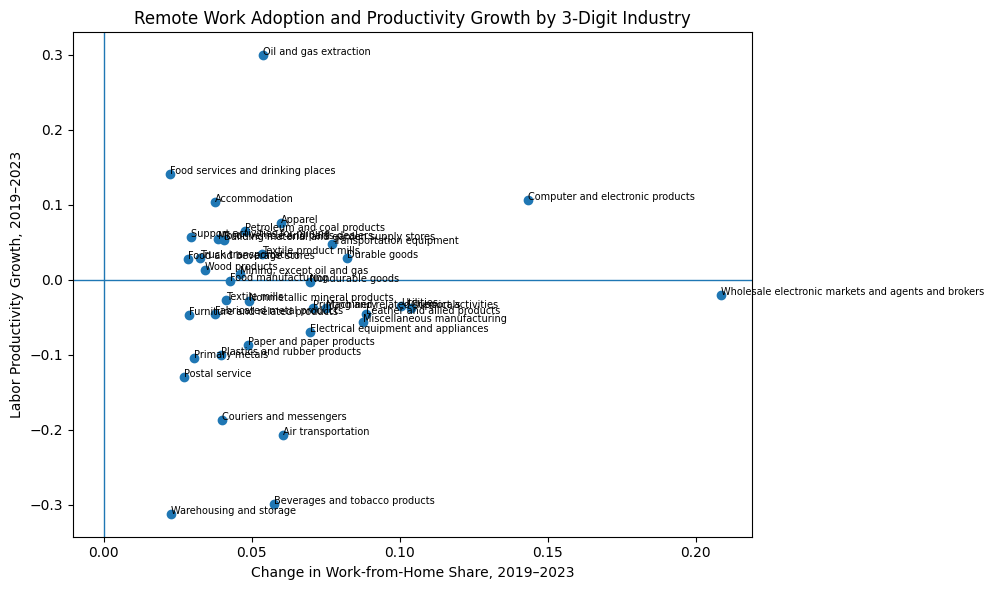

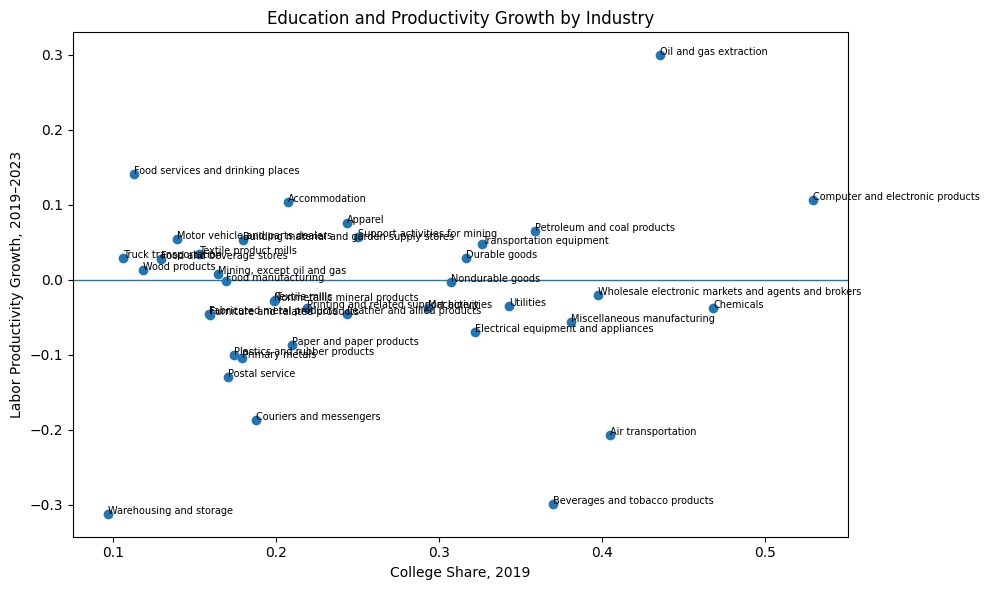


Saved:
- jrl_004_3digit_remote_productivity_dataset.csv
- jrl_004_3digit_regression_comparison.csv


In [14]:
# ============================================================
# JRL #004 — 3-Digit Industry Productivity Merge
# Next-stage analysis block
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

IPUMS_FILE = "usa_00002.dat.gz"
BLS_FILE = "labor-productivity-detailed-industries.xlsx"

# -----------------------------
# 1. Read IPUMS fixed-width data
# -----------------------------

colspecs = [
    (0, 4),      # YEAR
    (73, 83),    # PERWT
    (83, 85),    # EDUC
    (85, 88),    # EDUCD
    (88, 89),    # EMPSTAT
    (98, 106),   # INDNAICS
    (106, 108),  # TRANWORK
]

names = [
    "YEAR", "PERWT", "EDUC", "EDUCD",
    "EMPSTAT", "INDNAICS", "TRANWORK"
]

acs = pd.read_fwf(
    IPUMS_FILE,
    colspecs=colspecs,
    names=names,
    compression="gzip",
    dtype=str
)

for col in ["YEAR", "PERWT", "EDUC", "EDUCD", "EMPSTAT", "TRANWORK"]:
    acs[col] = pd.to_numeric(acs[col], errors="coerce")

acs["INDNAICS_clean"] = acs["INDNAICS"].astype(str).str.strip()

# -----------------------------
# 2. Build 3-digit ACS measures
# -----------------------------

acs_emp = acs[acs["EMPSTAT"] == 1].copy()

acs_emp["wfh"] = (acs_emp["TRANWORK"] == 80).astype(int)
acs_emp["college"] = (acs_emp["EDUCD"] >= 101).astype(int)

# Extract first three digits from ACS industry code
acs_emp["naics3"] = acs_emp["INDNAICS_clean"].str.extract(r"(\d{3})")[0]

acs_emp = acs_emp[
    acs_emp["naics3"].notna() &
    ~acs_emp["naics3"].isin(["000", "999"])
].copy()

print("ACS employed rows with 3-digit NAICS:", len(acs_emp))
print("Unique ACS 3-digit industries:", acs_emp["naics3"].nunique())

def weighted_mean(group, value_col, weight_col="PERWT"):
    valid = group[[value_col, weight_col]].dropna()
    if len(valid) == 0 or valid[weight_col].sum() == 0:
        return np.nan
    return np.average(valid[value_col], weights=valid[weight_col])

acs3 = (
    acs_emp
    .groupby(["YEAR", "naics3"])
    .apply(lambda x: pd.Series({
        "wfh_share": weighted_mean(x, "wfh"),
        "college_share": weighted_mean(x, "college"),
        "workers_weighted": x["PERWT"].sum()
    }))
    .reset_index()
)

acs3_wide = acs3.pivot(
    index="naics3",
    columns="YEAR",
    values=["wfh_share", "college_share", "workers_weighted"]
)

acs3_wide.columns = [f"{var}_{year}" for var, year in acs3_wide.columns]
acs3_wide = acs3_wide.reset_index()

acs3_wide["remote_change"] = acs3_wide["wfh_share_2023"] - acs3_wide["wfh_share_2019"]

print("\nACS 3-digit sample:")
print(acs3_wide.head())

# -----------------------------
# 3. Read BLS productivity data
# -----------------------------

prod = pd.read_excel(BLS_FILE, sheet_name="MachineReadable")

prod.columns = [
    "sector", "naics", "industry", "digit", "basis",
    "measure", "units", "year", "value"
]

prod["year"] = pd.to_numeric(prod["year"], errors="coerce")
prod["value"] = pd.to_numeric(prod["value"], errors="coerce")
prod["naics"] = prod["naics"].astype(str).str.strip()

prod["naics3"] = prod["naics"].str.extract(r"(\d{3})")[0]

prod3 = prod[
    (prod["measure"] == "Labor productivity") &
    (prod["basis"] == "All workers") &
    (prod["units"] == "Index (2017=100)") &
    (prod["digit"] == "3-Digit") &
    (prod["year"].isin([2019, 2023]))
].copy()

prod3_wide = (
    prod3
    .pivot_table(
        index=["naics3", "industry"],
        columns="year",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

prod3_wide.columns.name = None
prod3_wide = prod3_wide.rename(columns={
    2019: "prod_2019",
    2023: "prod_2023"
})

prod3_wide["prod_growth"] = prod3_wide["prod_2023"] / prod3_wide["prod_2019"] - 1

print("\nBLS 3-digit productivity industries:", len(prod3_wide))
print(prod3_wide.head(20))

# -----------------------------
# 4. Merge ACS + BLS
# -----------------------------

df3 = pd.merge(prod3_wide, acs3_wide, on="naics3", how="inner")

df3 = df3.dropna(subset=[
    "prod_growth",
    "remote_change",
    "college_share_2019",
    "wfh_share_2019",
    "wfh_share_2023"
]).copy()

df3 = df3.sort_values("remote_change", ascending=False).reset_index(drop=True)

print("\n====================================================")
print("FINAL 3-DIGIT MERGED DATASET")
print("====================================================")
print("Final sample size:", len(df3))

print(df3[[
    "naics3", "industry",
    "prod_growth",
    "wfh_share_2019",
    "wfh_share_2023",
    "remote_change",
    "college_share_2019"
]].to_string(index=False))

# -----------------------------
# 5. Correlations
# -----------------------------

corr_remote_college, p_remote_college = pearsonr(
    df3["remote_change"],
    df3["college_share_2019"]
)

corr_remote_prod, p_remote_prod = pearsonr(
    df3["remote_change"],
    df3["prod_growth"]
)

print("\n====================================================")
print("CORRELATIONS")
print("====================================================")
print(f"Remote change vs college share: r = {corr_remote_college:.3f}, p = {p_remote_college:.4f}")
print(f"Remote change vs productivity growth: r = {corr_remote_prod:.3f}, p = {p_remote_prod:.4f}")

# -----------------------------
# 6. Regressions
# -----------------------------

def run_ols(data, y_col, x_cols, label):
    y = data[y_col]
    X = sm.add_constant(data[x_cols])
    model = sm.OLS(y, X).fit(cov_type="HC1")
    print("\n====================================================")
    print(label)
    print("====================================================")
    print(model.summary())
    return model

model1 = run_ols(
    df3,
    "prod_growth",
    ["remote_change"],
    "MODEL 1: Productivity Growth ~ Remote Work Growth"
)

model2 = run_ols(
    df3,
    "prod_growth",
    ["remote_change", "college_share_2019"],
    "MODEL 2: Add College Share Control"
)

model3 = run_ols(
    df3,
    "prod_growth",
    ["remote_change", "college_share_2019", "wfh_share_2019"],
    "MODEL 3: Add Pre-Pandemic WFH Share"
)

comparison = pd.DataFrame({
    "model": ["Model 1", "Model 2", "Model 3"],
    "remote_change_coef": [
        model1.params.get("remote_change", np.nan),
        model2.params.get("remote_change", np.nan),
        model3.params.get("remote_change", np.nan)
    ],
    "remote_change_pvalue": [
        model1.pvalues.get("remote_change", np.nan),
        model2.pvalues.get("remote_change", np.nan),
        model3.pvalues.get("remote_change", np.nan)
    ],
    "r_squared": [
        model1.rsquared,
        model2.rsquared,
        model3.rsquared
    ],
    "n": [
        int(model1.nobs),
        int(model2.nobs),
        int(model3.nobs)
    ]
})

print("\n====================================================")
print("COEFFICIENT COMPARISON")
print("====================================================")
print(comparison.to_string(index=False))

# -----------------------------
# 7. Figures
# -----------------------------

plt.figure(figsize=(10, 6))
plt.scatter(df3["college_share_2019"], df3["remote_change"])

for _, row in df3.iterrows():
    plt.text(
        row["college_share_2019"],
        row["remote_change"],
        row["industry"],
        fontsize=7
    )

plt.xlabel("College Share, 2019")
plt.ylabel("Change in Work-from-Home Share, 2019–2023")
plt.title("Remote Work Adoption Was Concentrated in Highly Educated Industries")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(df3["remote_change"], df3["prod_growth"])

for _, row in df3.iterrows():
    plt.text(
        row["remote_change"],
        row["prod_growth"],
        row["industry"],
        fontsize=7
    )

plt.xlabel("Change in Work-from-Home Share, 2019–2023")
plt.ylabel("Labor Productivity Growth, 2019–2023")
plt.title("Remote Work Adoption and Productivity Growth by 3-Digit Industry")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(df3["college_share_2019"], df3["prod_growth"])

for _, row in df3.iterrows():
    plt.text(
        row["college_share_2019"],
        row["prod_growth"],
        row["industry"],
        fontsize=7
    )

plt.xlabel("College Share, 2019")
plt.ylabel("Labor Productivity Growth, 2019–2023")
plt.title("Education and Productivity Growth by Industry")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

# -----------------------------
# 8. Save outputs
# -----------------------------

df3.to_csv("jrl_004_3digit_remote_productivity_dataset.csv", index=False)
comparison.to_csv("jrl_004_3digit_regression_comparison.csv", index=False)

print("\nSaved:")
print("- jrl_004_3digit_remote_productivity_dataset.csv")
print("- jrl_004_3digit_regression_comparison.csv")